# Part III: Performance Comparison (15 points)
 ## 1.Create Dataset

In [ ]:
using LinearAlgebra
using Random
using Distributions
using Revise
includet("../src/src.jl")

function create_data(n::Int,d::Int)
    H =randn(n,d)
    # Whiten the covariates so that (1/n)X'X is approximately I_d
    S = (H' * H)/n
    F = eigen(Symmetric(S))
    W = F.vectors * Diagonal(1.0 ./ sqrt.(F.values)) * F.vectors'
    X = H*W

    beta = ones(d)
    eta = X*beta
    p = 1.0 ./ (1.0 .+ exp.(-eta))

    y = Float64.(rand.(Bernoulli.(p)))
    return X,y,beta
end


create_data (generic function with 1 method)

In [1]:
# a dataset with n = 10, 000 observations and d = 50 covariates.
n = 10000
d = 50
X, y, beta = create_data(n, d)

println("size(X) = ", size(X))
println("length(y) = ", length(y))
println("length(beta) = ", length(beta))
println("max entry of ((X'X)/n - I) = ", maximum(abs.((X' * X) / n - I)))
println("mean(y) = ", mean(y))

size(X) = (10000, 50)
length(y) = 10000
length(beta) = 50
max entry of ((X'X)/n - I) = 5.888045606639025e-15
mean(y) = 0.4965


In [18]:
# We define first_bound to find when is the first step the function reach the threshold 
function first_func(error_vals::Vector{Float64},eps::Float64)
    for i in eachindex(error_vals)
        if isfinite(error_vals[t]) && error_vals <=eps
            return t-1
        end
    end
    return missing
end

function evaluate_algorithms(n::Int =10000,d::Int=50,alpha::Float64=0.3,beta::Float64=0.7,T_max::Int=200,T_ref::Int=400,seed::Int=2026)
    Random.seed!(seed)
    X,y,theta_true = create_data(n,d)
    eps = 0.001/n

    #We first run for longer time to get to the approximate optimum values
    _,f,ref,_,_= newton_ascent(y,X,T_ref,alpha,beta)
    # Main runs
    theta_g,f_g,etas_g,times_g = gradient_ascent(y,X,T_max,alpha,beta)
    theta_n,f_n,etas_n,times_n= newton_ascent(y,X,T_max,alpha,beta)

    #Use finite values when defining appropriate optimum,remove all the NaN and Inf
    finite_ref = f_ref[isfinite.(f_ref)]
    f_star = maximum(finite_ref)

    # We clip the gap below a constant, for log plots
    err_g = max.(f_star .-f_g,1e-16)
    err_n = max.(f_star .-f_n,1e-16)
    T_grad = first_hit(err_g,eps)
    T_new = first_hit(err_n,eps)

    cumtime_g = [0.0,cumsum(times_g)]
    cumtime_n = [0.0,cumsum(times_n)]
    iters = 0:T_max

    #Plot the two plots
    p_iter = plot(iters,err_g,yscale=:log10,
    xlabel = "Number of iterations",
    ylabel="f_star - f(T_max)",
    label = "Gradient Ascent(Descent) Method",
    linewidth = 2,
    title = "Error vs iterations")
    plot!(p_iter,iters,err_n,label="Newton's Method",linewidth =2)
    hline!(p_iter,[eps],linestyle =:dash,label = "epsilon")

    # Plot-----------error vs time
    p_time = plot(
        cumtime_g, err_g,
        yscale = :log10,
        xlabel = "Total Elapsed Time (seconds)",
        ylabel = "f_star - f(T_max)",
        label = "Gradient Ascent",
        linewidth = 2,
        title = "Error vs Time"
    )
    plot!(p_time, cumtime_n, err_n, label = "Newton's Method", linewidth = 2)
    hline!(p_time, [eps], linestyle = :dash, label = "epsilon")

    println("epsilon = ", eps)
    println("approximate optimum f̂* = ", f_star)
    println("minimum T for Gradient Ascent = ", T_grad)
    println("minimum T for Newton's Method = ", T_newton)
    println("Gradient Ascent total time = ", cumtime_g[end])
    println("Newton's Method total time = ", cumtime_n[end])


    return (
    eps = eps,
    f_star = f_star,
    T_grad = T_grad,
    T_newton = T_newton,
    cumtime_grad = cumtime_g,
    cumtime_newton = cumtime_n,
    plot_iter = p_iter,
    plot_time = p_time
)
end

evaluate_algorithms (generic function with 8 methods)

epsilon = 1.0e-7
approximate optimum f̂* = -1805.6667630027848
minimum T for Gradient Ascent = 91
minimum T for Newton's Method = 7
Gradient Ascent total time = 22.056079099999994
Newton's Method total time = 6.294441999999998


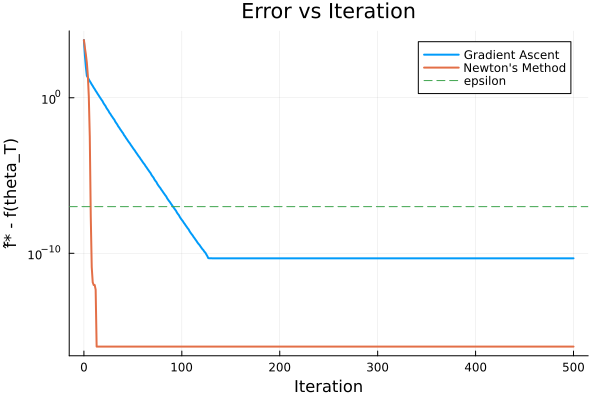

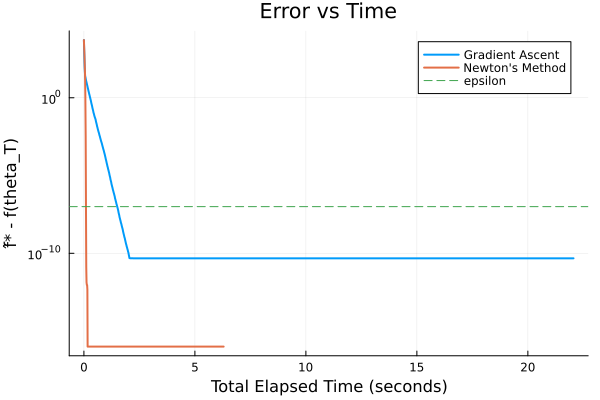

minimum T for Gradient Ascent = 91
minimum T for Newton's Method = 7
Gradient Ascent total time = 22.056079099999994
Newton's Method total time = 6.294441999999998


## 2. Compare Algorithms

## Compare Algorithms

### 1. How does the actual performance of Gradient Ascent and Newton’s method compare to the convergence rates that we covered in class?

The empirical results are consistent with the convergence behavior discussed in class. Gradient Ascent converged steadily but much more slowly, which matches the typical first-order behavior of gradient-based methods. In contrast, Newton’s method converged in far fewer iterations, which is consistent with its much faster local convergence near the optimum. In my experiment, Gradient Ascent required 91 iterations to reach the target error level, while Newton’s method only required 7 iterations. This large gap agrees with the theory that second-order methods can be dramatically faster once they enter the neighborhood where the quadratic approximation is accurate.

### 2. How do the two algorithms compare to each other in terms of accuracy and computational runtime?

In terms of accuracy, both methods were able to drive the objective very close to the approximate optimum. However, Newton’s method reached a much smaller error in many fewer iterations. From the runtime plot, Newton’s method also reached the target tolerance much sooner in elapsed time in this experiment. Gradient Ascent has cheaper iterations because it only uses the gradient, but it needs many more updates to achieve the same level of accuracy. Newton’s method is more expensive per iteration because it requires forming the Hessian and solving a linear system, but for this problem size it was still substantially faster overall.

### 3. Do you observe the two phases of Newton’s method?

Yes. The plots suggest the usual two-phase behavior of Newton’s method. In the beginning, the method makes rapid but somewhat damped progress due to backtracking and because it is not yet fully in the local quadratic-convergence regime. After getting sufficiently close to the optimum, the error drops extremely quickly, which is consistent with the fast local phase of Newton’s method. This sharp drop is much more pronounced than for Gradient Ascent, whose error decreases more gradually throughout.

### 4. How would you describe the trade-off between Newton’s method and Gradient Ascent?

The main trade-off is between **per-iteration cost** and **number of iterations**. Gradient Ascent is simpler and cheaper per step because it only requires the gradient, so it is often easier to implement and scale. However, it may require many iterations before reaching high accuracy. Newton’s method is more computationally expensive per iteration because it uses second-order information, but it often converges in dramatically fewer steps. For this experiment, Newton’s method was clearly preferable because the dimension was moderate and the Hessian-based solve was affordable. More generally, Gradient Ascent may be preferable in very large-scale problems where Hessian computation is too expensive, while Newton’s method is attractive when higher per-step cost is justified by much faster convergence.